# Exploration of the HD model of sound responses of thalamic HD cells

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider
from scipy.optimize import minimize
from scipy.io import loadmat

In [2]:
# Constants
N = 100 # 100 neurons
THETA = np.linspace(-np.pi, np.pi, N, endpoint = False) # Assignment of PD for the neurons

DT = 0.2 # temporal precision; default 0.5 ms
T = 500 # decay time for phasic response
T_BURN_IN = -50 # 50 ms for the model initialization to settle
T_END = 600
TIME = np.arange(T_BURN_IN, T_END, DT)

I_BASELINE = 34.27 # Baseline Activity drive
I_TUNING_CUE = 5 # external afferent input to visualize the Network tuning across all angles
SIGMA_CUE = np.deg2rad(15) # spatial tuning of the cue

FC_STIM_DURATION = 2 # 2ms of Step function Input
A_FAST = 800 # FC Activity drive
A_PHASIC = 60 # SC Activity drive
SIGMA_PHASIC = np.deg2rad(10) # spatial width for the phasic response

TAU_NEURAL = 10 # Neural Time constant
TAU_PHASIC_DECAY = 100 # Decay function for phasic response

T_STIM = 100 # Stimulus onset
T_PHASIC = 110 # Phasic onset at 55ms

J1 = 8.27 # Strength for local excitatory recurrent connections between cells with similar PD
J0 = 2.01 # Strength of uniform global inhibition
KAPPA = 9 # Higher = sharper tuning curve. Move from cosine connectivity to von Mises

W = np.zeros((N, N)) # Connectivity Matrix
tuning_heatmap = np.zeros((N, N))
times_to_plot = [90, 101, 110, 150]

#####
# checkpoint values
# I_BASELINE = 20
# J1 = 8.27
# J0 = 2.5
# KAPPA = 9
#####

In [3]:
# Initialization of Connectivity matrix
for a in range(N):
    for b in range(N):
        d_theta = np.angle(
            np.exp(1j * (THETA[a] - THETA[b]))
        )
        W[a, b] = J1 * np.exp(KAPPA * (np.cos(d_theta) - 1.0)) - J0
W = W / N # Weight Normalziation

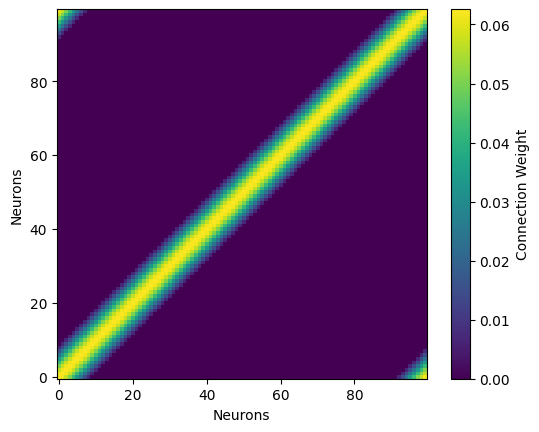

In [4]:
plt.imshow(W, origin = 'lower', vmin = 0)
plt.xlabel('Neurons')
plt.ylabel('Neurons')
plt.colorbar(label = 'Connection Weight')
plt.show()

In [5]:
# Connectivity visualization

def plot_mexican_hat(J1=4.0, J0=1.5):
    """
    Plots the Mexican Hat synaptic connectivity kernel.
    """
    # 1. Create the angular array (-180 to 180 degrees)
    theta_deg = np.linspace(-180, 180, 500)
    theta_rad = np.radians(theta_deg)
    
    # 2. Calculate the synaptic weight W
    # Formula: W(theta) = J1 * cos(theta) - J0
    W = J1 * np.cos(theta_rad) - J0
    
    # 3. Set up the plot
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot the main curve
    ax.plot(theta_deg, W, color='black', linewidth=2)
    
    # Add a zero-line to distinguish excitation from inhibition
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.5)
    
    # Visually shade the excitatory (positive) and inhibitory (negative) regions
    ax.fill_between(theta_deg, W, 0, where=(W > 0), 
                    interpolate=True, color='tomato', alpha=0.4, label='Local Excitation (W > 0)')
    ax.fill_between(theta_deg, W, 0, where=(W <= 0), 
                    interpolate=True, color='royalblue', alpha=0.4, label='Global Inhibition (W < 0)')
    
    # 4. Formatting
    ax.set_title('Mexican Hat Synaptic Kernel\n$W(\\Delta\\theta) = J_1 \\cos(\\Delta\\theta) - J_0$', fontsize=14)
    ax.set_xlabel('Angular Distance $\\Delta\\theta$ (Degrees)', fontsize=12)
    ax.set_ylabel('Synaptic Weight ($W$)', fontsize=12)
    
    # Keep the X-axis fixed to a full circle
    ax.set_xlim(-180, 180)
    ax.set_xticks([-180, -90, 0, 90, 180])
    
    # Dynamically scale the Y-axis so the plot doesn't jump around too erratically
    max_height = max(10, J1)
    ax.set_ylim(-max_height - 2, max_height + 2)
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.show()

# 5. Connect the function to interactive sliders
#interact(plot_mexican_hat,
#         J1=FloatSlider(value=J1, min=0.0, max=10.0, step=0.1, description='J1 (Excitation):', style={'description_width': 'initial'}),
#         J0=FloatSlider(value=J0, min=0.0, max=15.0, step=0.1, description='J0 (Inhibition):', style={'description_width': 'initial'}));

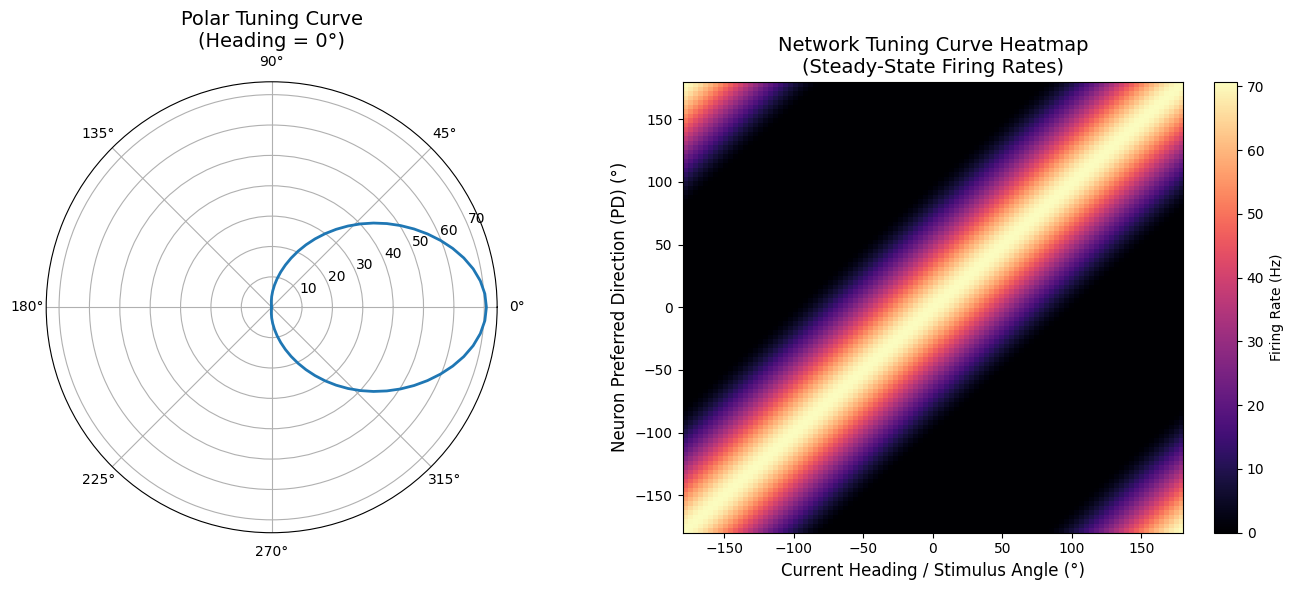

In [6]:
# investigation of tuning for created HD cells
for h_idx, heading in enumerate(THETA):
    # Flat initialization fo the network
    d_theta_cue = np.angle(np.exp(1j * (THETA - heading)))
    u = 40.0 * np.maximum(0, np.cos(d_theta_cue))
    r = np.maximum(0, u)

    I_ext = I_BASELINE + I_TUNING_CUE * np.exp(-0.5 * (d_theta_cue / SIGMA_CUE)**2)

    # Run integration until the bump stabilizes at the heading
    for t in TIME:
        u  += (-u + W @ r + I_ext) * (DT/TAU_NEURAL) # compute the neurons activity per time
        r = np.maximum(0, u)

    tuning_heatmap[:, h_idx] = r

fig = plt.figure(figsize=(14, 6))

# --- Panel 1: Cartesian Heatmap ---
# add_subplot(1, 2, 1) means: 1 row, 2 columns, 1st plot
ax1 = fig.add_subplot(1, 2, 2) 

im = ax1.imshow(
    tuning_heatmap,
    origin='lower',
    aspect='auto',
    extent=[-180, 180, -180, 180],
    cmap='magma',
    vmin=0, 
    vmax=np.max(tuning_heatmap),
)
ax1.set_title("Network Tuning Curve Heatmap\n(Steady-State Firing Rates)", fontsize=14)
ax1.set_xlabel("Current Heading / Stimulus Angle (°)", fontsize=12) # Fixed spelling
ax1.set_ylabel("Neuron Preferred Direction (PD) (°)", fontsize=12)  # Fixed from xlabel to ylabel
fig.colorbar(im, ax=ax1, label="Firing Rate (Hz)")

# --- Panel 2: Polar Plot ---
# add_subplot(1, 2, 2) means: 1 row, 2 columns, 2nd plot. 
# We explicitly set the projection to 'polar' here.
ax2 = fig.add_subplot(1, 2, 1, projection='polar')

# THETA is already in radians (-pi to pi), which Matplotlib's polar projection requires!
# Index 50 corresponds exactly to heading = 0 degrees
ax2.plot(THETA, tuning_heatmap[:, 50], color='tab:blue', linewidth=2)
ax2.set_title("Polar Tuning Curve\n(Heading = 0°)", fontsize=14)

plt.tight_layout()
plt.show()

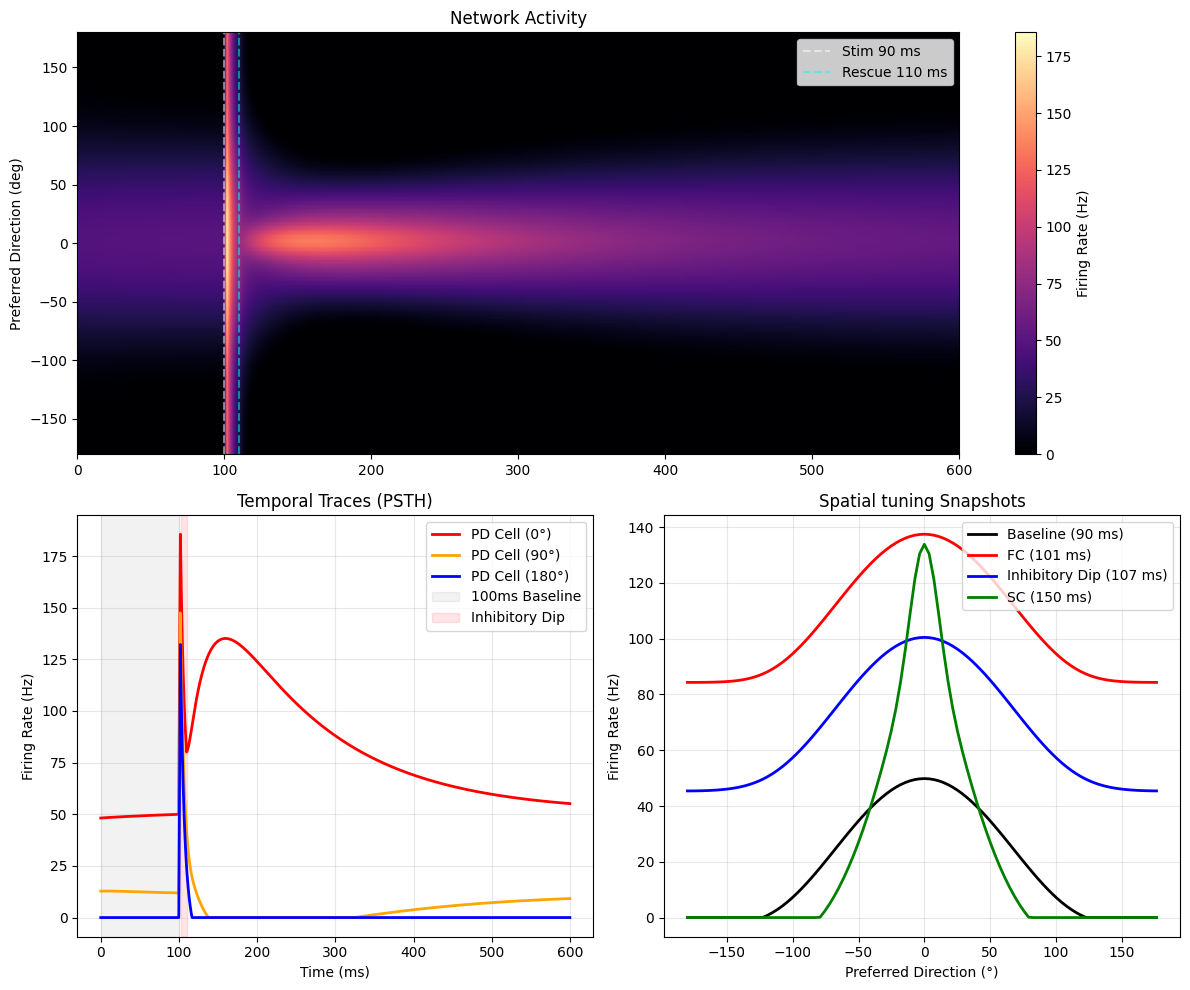

In [7]:
## Implement the Stimulus injection at constant heading
# initialize the model
u = 40 * np.maximum(0, np.cos(THETA)) # Firing rate
r = np.maximum(0, u) # ReLU for Firing

dRate_dt = np.zeros((len(TIME), N))

for step, t in enumerate(TIME):
    I_ext = np.ones(N) * I_BASELINE # Set output to Baseline activity
    # Phase 1: Fast component
    if T_STIM <= t < (T_STIM + FC_STIM_DURATION):
        I_ext += A_FAST # Step function for the FC for the specified duration

    # Phase 2: Slow component, spatially restricted
    elif t >= T_PHASIC:
        decay_factor = np.exp(-(t - T_PHASIC) / TAU_PHASIC_DECAY)
        I_ext += A_PHASIC * decay_factor * np.exp(-0.5 * (THETA / SIGMA_PHASIC)**2) # addition of Spatial constraint

    # Continuous Attractor Neural Network (CANN) Equation
    du = (-u + W @ r + I_ext) * (DT / TAU_NEURAL)
    u += du
    r = np.maximum(0, u) # Apply ReLU again
    dRate_dt[step, :] = r

# cut initializtation time
initialization_mask = TIME >= 0
time_plot = TIME[initialization_mask]
rates_plot = dRate_dt[initialization_mask, :]

# Visualization
fig = plt.figure(figsize = (12, 10))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, :])
im = ax1.imshow(
    rates_plot.T, aspect = 'auto',
    origin = 'lower',
    extent = [0, T_END, -180, 180],
    cmap = 'magma',
    vmin = 0,
)
ax1.set_ylabel("Preferred Direction (deg)")
ax1.set_title("Network Activity")
ax1.axvline(
    T_STIM, color = 'white',
    linestyle = '--',
    alpha = 0.5,
    label = f"Stim {T_STIM - 10} ms",
)
ax1.axvline(
    T_PHASIC, color = 'cyan',
    linestyle = '--',
    alpha = 0.5,
    label = f"Rescue {T_PHASIC} ms",
)
ax1.legend(loc = 'upper right')
fig.colorbar(im, ax=ax1, label = "Firing Rate (Hz)")

# Single Cell temporal Trace
ax2 = fig.add_subplot(gs[1, 0])
idx_0 = np.argmin(np.abs(THETA))
idx_90 = np.argmin(np.abs(THETA - np.pi/2))
idx_180 = np.argmin(np.abs(THETA- np.pi))

ax2.plot(time_plot, rates_plot[:, idx_0],
         label = "PD Cell (0°)",
         color = "red",
         lw = 2)

ax2.plot(time_plot, rates_plot[:, idx_90],
         label = "PD Cell (90°)",
         color = "orange",
         lw = 2)

ax2.plot(time_plot, rates_plot[:, idx_180],
         label = "PD Cell (180°)",
         color = "blue",
         lw = 2)

ax2.axvspan(0, T_STIM, color = "gray", alpha = 0.1, label = "100ms Baseline")
ax2.axvspan(T_STIM + FC_STIM_DURATION, T_PHASIC, color = "red", alpha = 0.1, label = "Inhibitory Dip")

ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("Firing Rate (Hz)")
ax2.set_title("Temporal Traces (PSTH)")
ax2.legend(loc = 'upper right')
ax2.grid(True, alpha = 0.3)

# Temporal snapshots of the attractor
ax3 = fig.add_subplot(gs[1,1])
colors = ['black', 'red', 'blue', 'green']

base_names = ['Baseline', 'FC', 'Inhibitory Dip', 'SC']

labels = [f"{name} ({time} ms)" for name, time in zip(base_names, times_to_plot)]

for t_target, color, label in zip(times_to_plot, colors, labels):
    step_idx = int(t_target / DT)
    ax3.plot(np.rad2deg(THETA), rates_plot[step_idx, :], label = label, color = color, lw = 2)

ax3.set_xlabel("Preferred Direction (°)")
ax3.set_ylabel("Firing Rate (Hz)")
ax3.set_title("Spatial tuning Snapshots")
ax3.legend(loc = 'upper right')
ax3.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()




In [23]:
# load average firing curve

mat = loadmat('mean_7_rate.mat')

In [25]:
bins_plot = mat['bins_plot'][0]
mean_seven_rate = mat['mean_seven_rate'][0]

Starting optimization... (this may take 10-20 seconds)

--- Optimization Complete ---
Optimal J1 (Excitation):     8.27
Optimal J0 (Inhibition):     2.01
Optimal I_BASE (Background): 34.26


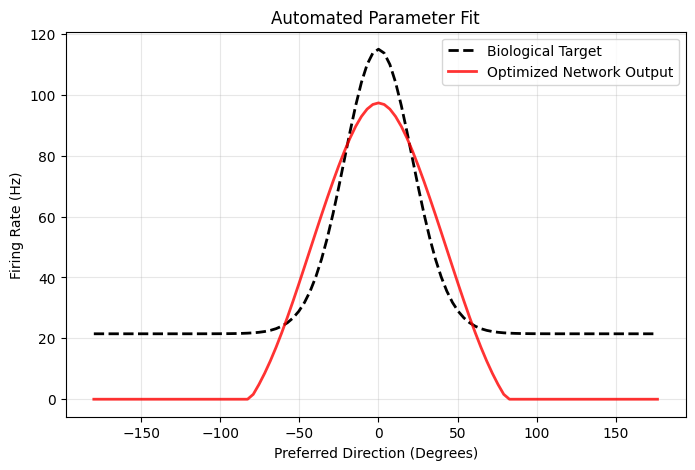

In [8]:
# ==========================================
# 1. Define Your Biological Target
# ==========================================
TARGET_PEAK = 115.0      # From your cell metadata
TARGET_BASE = 21.5       # From your cell metadata
TARGET_KAPPA = 7.0       # The desired sharpness of the tuning curve

N = 100
THETA = np.linspace(-np.pi, np.pi, N, endpoint=False)

# Create the "Perfect" target tuning curve we want the network to achieve
target_tuning_curve = TARGET_BASE + (TARGET_PEAK - TARGET_BASE) * np.exp(TARGET_KAPPA * (np.cos(THETA) - 1.0))

# ==========================================
# 2. The Simulation Function
# ==========================================
def simulate_steady_state(J1, J0, I_base, kappa=TARGET_KAPPA):
    """Runs the network to steady state and returns the tuning curve."""
    # Build the weight matrix
    W = np.zeros((N, N))
    for a in range(N):
        for b in range(N):
            d_theta = np.angle(np.exp(1j * (THETA[a] - THETA[b])))
            W[a, b] = J1 * np.exp(kappa * (np.cos(d_theta) - 1.0)) - J0
    W = W / N
    
    # Initialization (Seeding the bump)
    u = TARGET_PEAK * np.maximum(0, np.cos(THETA))
    r = np.maximum(0, u)
    
    # Run integration (shorter time is fine for just finding steady state)
    dt = 0.5
    tau = 10.0
    for t in np.arange(0, 100, dt):
        # We assume heading is 0, so external cue is centered at 0
        I_cue = 5.0
        sigma_cue = np.deg2rad(15)
        I_ext = I_base + I_cue * np.exp(-0.5 * (THETA / sigma_cue)**2)
        
        u += (-u + W @ r + I_ext) * (dt / tau)
        r = np.maximum(0, u)
        
    return r

# ==========================================
# 3. The Objective (Loss) Function
# ==========================================
def loss_function(params):
    """Calculates how far off the current network is from the perfect target."""
    J1, J0, I_base = params
    
    # Run the simulation with the current guesses
    simulated_curve = simulate_steady_state(J1, J0, I_base)
    
    # Calculate the Mean Squared Error (MSE)
    error = np.mean((simulated_curve - target_tuning_curve)**2)
    return error

# ==========================================
# 4. Run the Optimizer
# ==========================================
print("Starting optimization... (this may take 10-20 seconds)")

# Initial Guesses: [J1, J0, I_base]
initial_guess = [5.0, 2.0, 30.0]

# Bounds: Prevent the optimizer from trying mathematically invalid negative weights
bounds = [(1.0, 20.0),  # J1 must be positive
          (0.0, 10.0),  # J0 must be positive
          (0.0, 100.0)] # I_base must be positive

# Run the L-BFGS-B algorithm
result = minimize(loss_function, initial_guess, bounds=bounds, method='L-BFGS-B')

best_J1, best_J0, best_I_base = result.x

print("\n--- Optimization Complete ---")
print(f"Optimal J1 (Excitation):     {best_J1:.2f}")
print(f"Optimal J0 (Inhibition):     {best_J0:.2f}")
print(f"Optimal I_BASE (Background): {best_I_base:.2f}")

# ==========================================
# 5. Visual Proof
# ==========================================
best_simulated_curve = simulate_steady_state(best_J1, best_J0, best_I_base)

plt.figure(figsize=(8, 5))
plt.plot(np.rad2deg(THETA), target_tuning_curve, 'k--', lw=2, label="Biological Target")
plt.plot(np.rad2deg(THETA), best_simulated_curve, 'r-', lw=2, alpha=0.8, label="Optimized Network Output")
plt.title("Automated Parameter Fit")
plt.xlabel("Preferred Direction (Degrees)")
plt.ylabel("Firing Rate (Hz)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()